In [161]:
class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self.grad = 0.0
        self._prev = _children
        self._op = _op
        self.label = label
        self._backward = lambda:None

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),"+")

        def _backward():
            self.grad = out.grad
            other.grad = out.grad

        out._backward = _backward

        return out
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self,other),"*")

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward
        
        return out
    
    def __repr__(self):
        return f"Value: {self.data}"
    
    def backward(self):
        visited = set()
        topo = []
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()


In [162]:
v1 = Value(2);v1.label = "v1"
v2 = Value(3);v2.label = "v2"

In [163]:
v3 = v1+v2
v3._prev

(Value: 2, Value: 3)

In [164]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


from graphviz import Digraph

def draw_dots(root):
    nodes,edges = trace(root)
    dot = Digraph(name="graph",format='svg',graph_attr={"rankdir":"LR"})

    for n in nodes:
        uid = str(id(n))
        dot.node(uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape='record')

        if n._op:
            dot.node(uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for e1,e2 in edges:
        dot.edge(str(id(e1)),str(id(e2))+e2._op)

    return dot
    
    

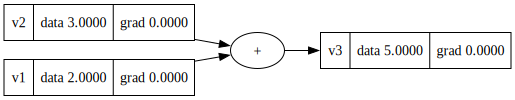

In [165]:
v3.label = "v3"
draw_dots(v3) 

In [166]:
a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
l

Value: -8.0

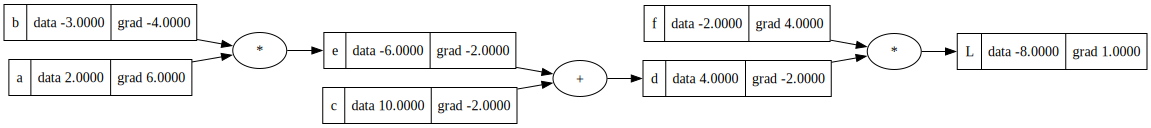

In [171]:
draw_dots(l)

In [168]:
l.backward()

In [169]:
l.grad = 1.0

In [ ]:
# l._backward()
# d._backward()
# e._backward()

l = df

dl/dd = f * dl/dl

dd/dl = dd/dl * dl/dl

d = e +c 
dd/de = 1
dd/dl = dd/de * de/dl